In [44]:

from statistics import linear_regression

#Lab 08
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.linear_model import LinearRegression

def gradient_descent(x, y, lr, epochs=100):
    n = len(x)
    losses = []
    a, b = 0.0, 0.0
    for i in range(epochs):
        y_pred = a * x + b

        #compute loss
        loss = np.mean((y - y_pred) **2)
        losses.append(loss)

        #Compute gradients
        da = (-2/n) * np.sum(x * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)

        #update parameters
        a -= lr * da
        b -= lr * db
    return a, b, losses

import matplotlib.pyplot as plt

def plot_grid(data_list, titles, kind='line', cols=3, figsize=(15, 5)):
    rows = int(np.ceil(len(data_list)/cols))
    plt.figure(figsize=figsize)

    for i, data in enumerate(data_list):
        plt.subplot(rows, cols, i+1)
        if kind == 'line':
            x_line, y_line, x_data, y_data = data
            plt.scatter(x_data, y_data, label="Data")
            plt.plot(x_line, y_line, color='red', label="Fitted line")
            plt.legend()
        elif kind == 'loss':
            (losses,) = data
            plt.plot(losses)
            plt.xlabel("Iteration")
            plt.ylabel("MSE Loss")
        plt.title(titles[i])
    plt.tight_layout()
    plt.show()

Final a: 2.93, Final b: 0.42


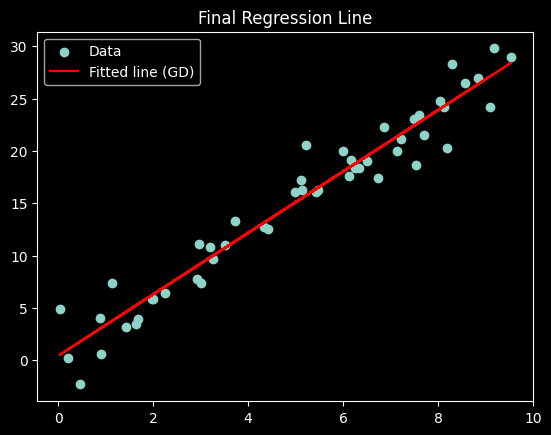

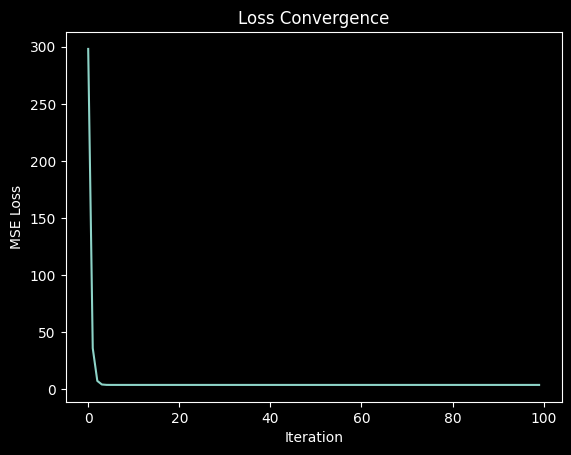

In [45]:
#Create Dataset
np.random.seed(10)
x = np.random.rand(50,1) * 10
noise = np.random.randn(50,1) * 2
y = 3 * x + noise

# learning rate
learning_rates = 0.01

a, b, losses = gradient_descent(x, y, learning_rates)


print(f"Final a: {a:.2f}, Final b: {b:.2f}")

y_final = a * x + b

#plotting
plt.scatter(x, y, label="Data")
plt.plot(x, y_final, color='red', label="Fitted line (GD)")
plt.legend()
plt.title("Final Regression Line")
plt.show()

plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Loss Convergence")
plt.show()



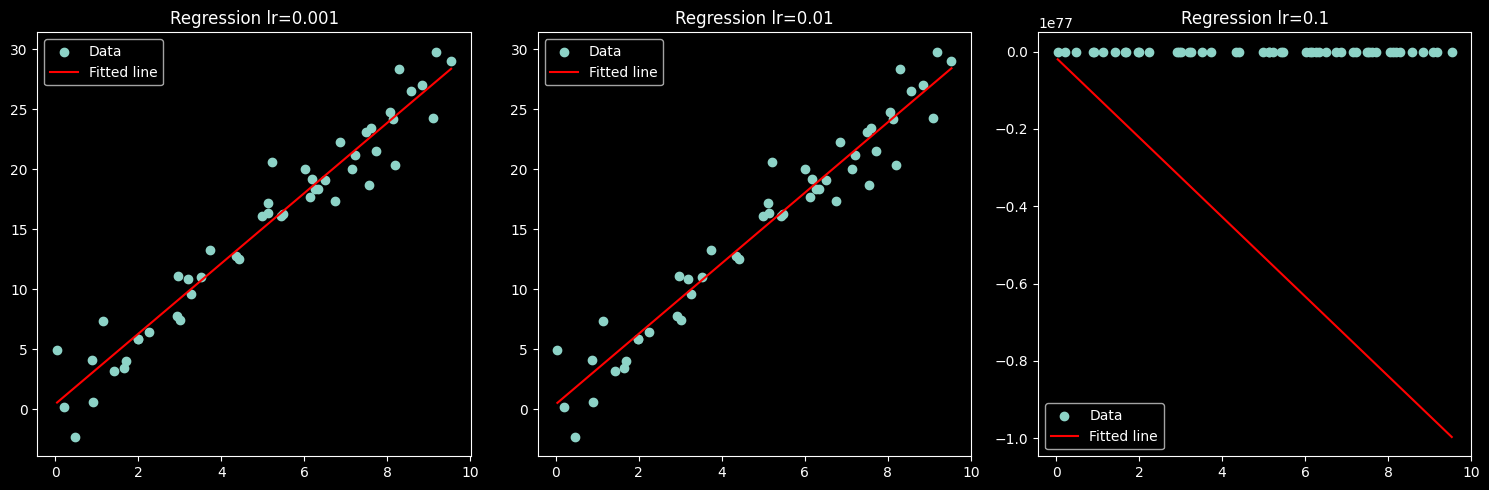

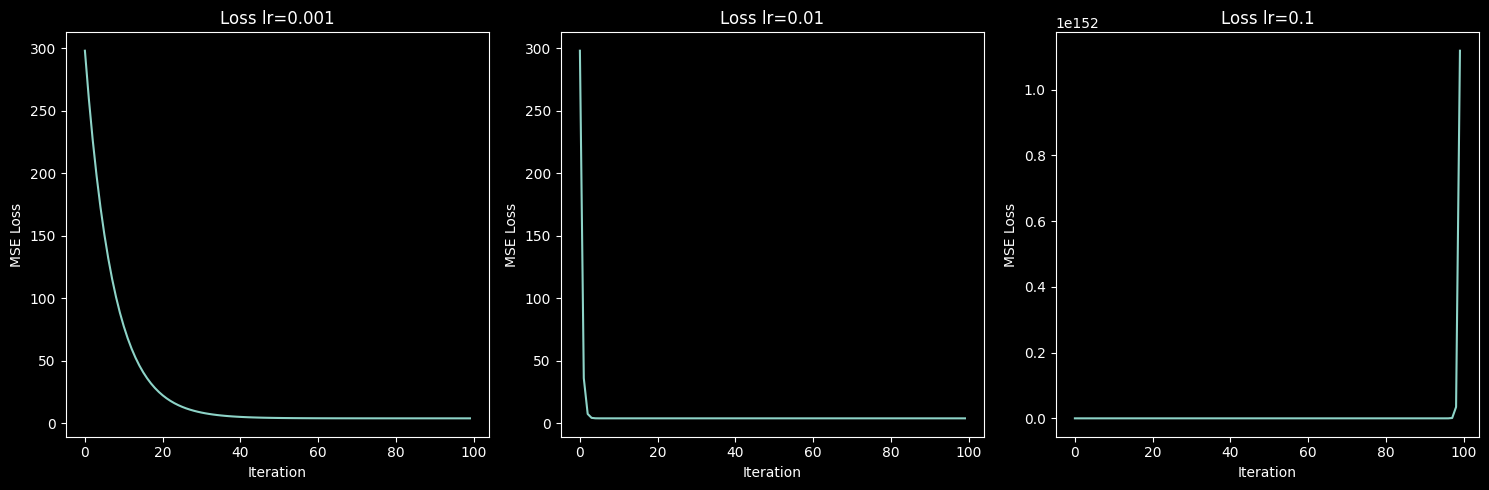

In [46]:
learning_rates = [0.001, 0.01, 0.1]
results = {}

# Run gradient descent
for lr in learning_rates:
    a, b, losses = gradient_descent(x, y, lr)
    results[lr] = (a, b, losses)

# Prepare data for regression line grid
regression_data = []
regression_titles = []
for lr in learning_rates:
    a, b, _ = results[lr]
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = a * x_line + b
    regression_data.append((x_line, y_line, x, y))
    regression_titles.append(f"Regression lr={lr}")

plot_grid(regression_data, regression_titles, kind='line')

# Prepare data for loss convergence grid
loss_data = []
loss_titles = []
for lr in learning_rates:
    _, _, losses = results[lr]
    loss_data.append((losses,))
    loss_titles.append(f"Loss lr={lr}")

#plotting
plot_grid(loss_data, loss_titles, kind='loss')

Questions
18. Why can a learning rate that is too large prevent convergence?
    - If the learning rate is too large it will overstep, instead of stepping towards it
19. Why can a learning rate that is too small make optimisation inefficient?
    - Convergence can be very slow, taking more iterations than needed to reach the minimum.
    - It can be more innefficient
20. How could you automatically decide when to stop the optimisation?
    - Instead of having a fixed number of iterations, we can use a calculate when to stop
    - This could be if the loss is close to zero, or the gradients are close to zero
